In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)


In [2]:
df = pd.read_csv("/content/Telco-Customer-Churn.csv")

print(df.head())
print(df.shape)
print(df.info())


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [3]:
print(df.isnull().sum())
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"], errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)
df = df.drop("customerID", axis=1)
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})
X = df.drop("Churn", axis=1)
y = df["Churn"]

X = pd.get_dummies(X, drop_first=True)

print(X.head())


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85        False   
1              0      34           56.95       1889.50         True   
2              0       2           53.85        108.15         True   
3              0      45           42.30       1840.75         True   
4              0       2           70.70        151.65        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             Fal

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (5634, 30)
Testing data: (1409, 30)


In [5]:
dt_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)


DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

In [6]:
y_pred = dt_model.predict(X_test)

print("Predictions:")
print(y_pred[:20])


Predictions:
[0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]


Confusion Matrix:
[[939  96]
 [197 177]]


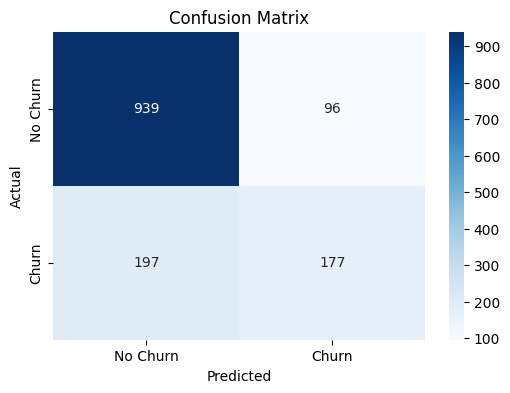

In [7]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [8]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
precision = precision_score(y_test, y_pred)
print("Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("F1-Score:", f1)
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Churn", "Churn"]
))


Accuracy: 0.7920511000709723
Precision: 0.6483516483516484
Recall: 0.4732620320855615
F1-Score: 0.5471406491499228
              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1035
       Churn       0.65      0.47      0.55       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



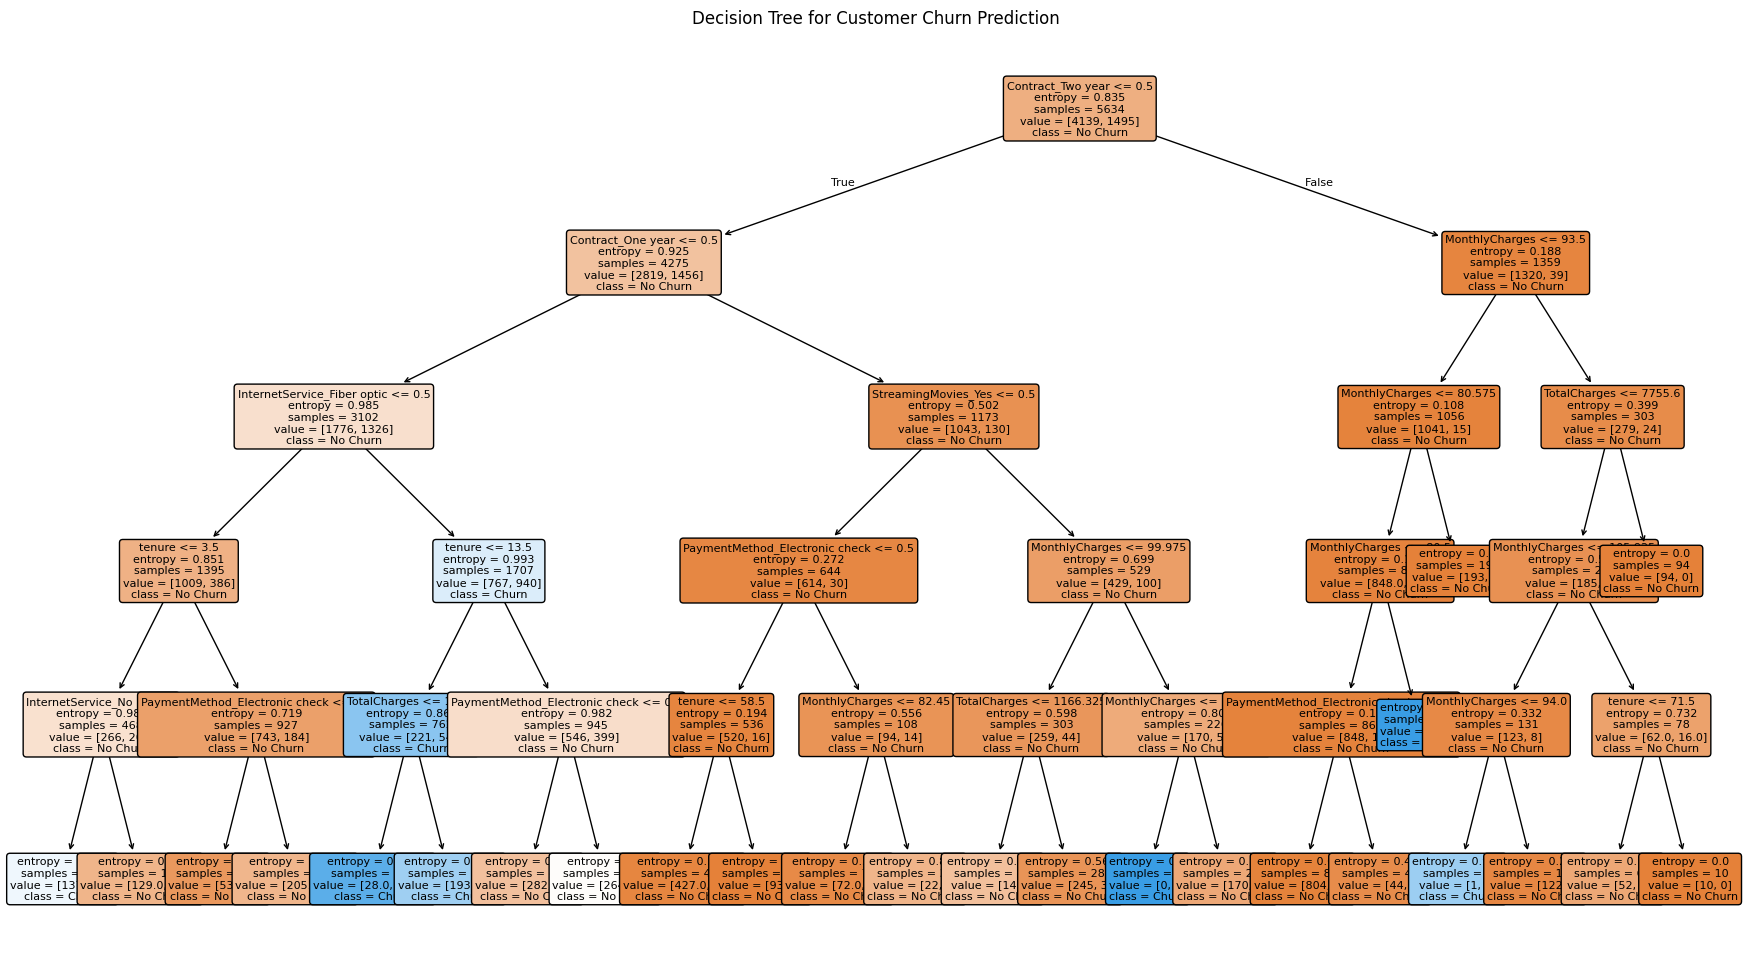

In [9]:
plt.figure(figsize=(22, 12))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["No Churn", "Churn"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree for Customer Churn Prediction")
plt.show()


In [10]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))


                           Feature  Importance
25               Contract_Two year    0.360941
24               Contract_One year    0.229034
10     InternetService_Fiber optic    0.127308
1                           tenure    0.125485
2                   MonthlyCharges    0.045965
28  PaymentMethod_Electronic check    0.037758
23             StreamingMovies_Yes    0.032553
3                     TotalCharges    0.028003
11              InternetService_No    0.012952
7                 PhoneService_Yes    0.000000


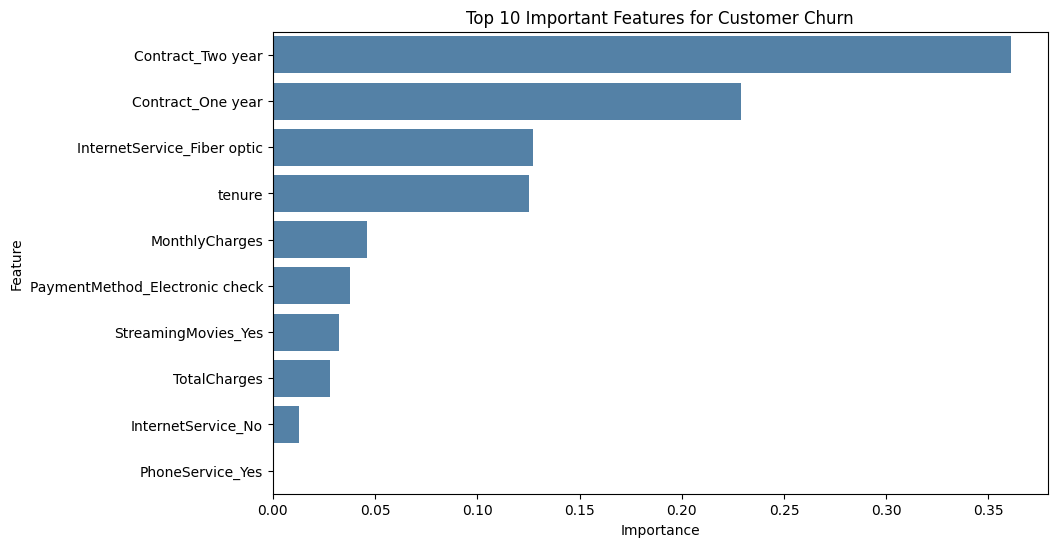

In [11]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature",
    color="steelblue"
)

plt.title("Top 10 Important Features for Customer Churn")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


In [12]:

new_customer = X_test.iloc[[0]]

prediction = dt_model.predict(new_customer)

if prediction[0] == 1:
    print("Customer is likely to churn.")
else:
    print("Customer is likely to stay.")


Customer is likely to stay.
